In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Read the CSV file into a DataFrame
df = pd.read_csv("mnt-oficial-IJ-117.csv")

# Display the first 5 rows
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(df.info())

| Cód. Ordem   | Cód. Recurso   | Cód. Produto   | Qtd. Produzida   | Qtd. Refugada   | Qtd. Retrabalhada   | Fator Un.   | Cód. Un.   | Descrição da massa (Composto)   | Consumo de massa no item em (Kg/100pçs)   | Qtd. Produzida Acumulada Total   | Qtd. Refugada Acumulada Total   | Qtd. Retrabalhada Acumulada Total   | Fator Un. Acumulado Total   | Consumo de massa no item em (Kg/100pçs) Acumulado Total   | Manutencao   |
|:-------------|:---------------|:---------------|:-----------------|:----------------|:--------------------|:------------|:-----------|:--------------------------------|:------------------------------------------|:---------------------------------|:--------------------------------|:------------------------------------|:----------------------------|:----------------------------------------------------------|:-------------|
| 2669220      | IJ-117         | SA02530        | 892              | 24              | 0                   | 3           | PC         | N148/18  

# Análise Exploratória Inicial

Este notebook inicia a análise exploratória dos dados, focando em algumas variáveis chave.

## Sumário de Quantidades

Vamos começar calculando e exibindo a soma das quantidades produzidas, refugadas e retrabalhadas:

```python
# Código para calcular e exibir as somas
soma_produzida = df['Qtd. Produzida'].sum()
soma_refugada = df['Qtd. Refugada'].sum()
soma_retrab = df['Qtd. Retrabalhada'].sum()

print(f"Soma da Qtd. Produzida: {soma_produzida}")
print(f"Soma da Qtd. Refugada: {soma_refugada}")
print(f"Soma da Qtd. Retrabalhada: {soma_retrab}")

In [3]:
# Calculate the sum of `Qtd. Produzida`, `Qtd. Refugada` and `Qtd. Retrabalhada`
qtd_produzida_sum = df["Qtd. Produzida"].sum()
qtd_refugada_sum = df["Qtd. Refugada"].sum()
qtd_retrabalhada_sum = df["Qtd. Retrabalhada"].sum()

# Print the sum of `Qtd. Produzida`, `Qtd. Refugada` and `Qtd. Retrabalhada`
print(f"Total Qtd. Produzida: {qtd_produzida_sum}")
print(f"Total Qtd. Refugada: {qtd_refugada_sum}")
print(f"Total Qtd. Retrabalhada: {qtd_retrabalhada_sum}")

# Print the unique values of `Fator Un.`
print(f"Unique values of Fator Un.: {df['Fator Un.'].unique()}")

# Print the unique values of `Cód. Un.`
print(f"Unique values of Cód. Un.: {df['Cód. Un.'].unique()}")

# Print the unique values of `Descrição da massa (Composto)`
print(
    f"Unique values of Descrição da massa (Composto): {df['Descrição da massa (Composto)'].unique()}"
)

# Calculate and print the correlation between `Qtd. Produzida`, `Qtd. Refugada` and `Qtd. Retrabalhada`
correlation = df[["Qtd. Produzida", "Qtd. Refugada", "Qtd. Retrabalhada"]].corr()
print("Correlation between Qtd. Produzida, Qtd. Refugada and Qtd. Retrabalhada:")
print(correlation.to_markdown(numalign="left", stralign="left"))

# Calculate and print the range of `Consumo de massa no item em (Kg/100pçs)`
consumo_massa_range = (
    df["Consumo de massa no item em (Kg/100pçs)"].min(),
    df["Consumo de massa no item em (Kg/100pçs)"].max(),
)
print(f"Range of Consumo de massa no item em (Kg/100pçs): {consumo_massa_range}")

Total Qtd. Produzida: 276484
Total Qtd. Refugada: 9378
Total Qtd. Retrabalhada: 0
Unique values of Fator Un.: [ 3  4  5  6  2  1 63]
Unique values of Cód. Un.: ['PC']
Unique values of Descrição da massa (Composto): ['N148/18' 'F403/32' 'F424/40' 'F420/191' 'S316/2' 'S315/10' 'P212/1'
 'P250/14' 'N146/9' 'N-142/67' 'F444/1' 'F420/95']
Correlation between Qtd. Produzida, Qtd. Refugada and Qtd. Retrabalhada:
|                   | Qtd. Produzida   | Qtd. Refugada   | Qtd. Retrabalhada   |
|:------------------|:-----------------|:----------------|:--------------------|
| Qtd. Produzida    | 1                | 0.0949586       | nan                 |
| Qtd. Refugada     | 0.0949586        | 1               | nan                 |
| Qtd. Retrabalhada | nan              | nan             | nan                 |
Range of Consumo de massa no item em (Kg/100pçs): (0.48, 20.172)


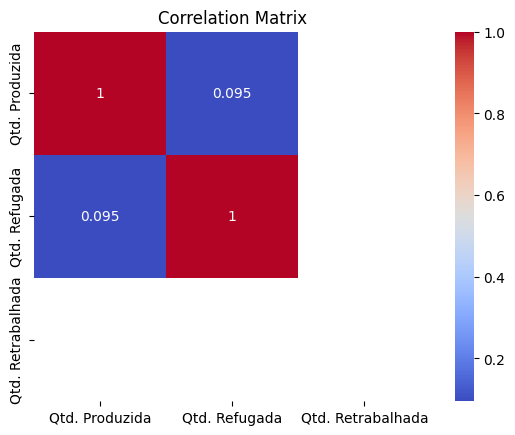

|       | Qtd. Produzida   | Qtd. Refugada   | Qtd. Retrabalhada   |
|:------|:-----------------|:----------------|:--------------------|
| count | 321              | 321             | 321                 |
| mean  | 861.321          | 29.215          | 0                   |
| std   | 390.155          | 23.3999         | 0                   |
| min   | 5                | 0               | 0                   |
| 25%   | 598              | 11              | 0                   |
| 50%   | 942              | 26              | 0                   |
| 75%   | 1182             | 42              | 0                   |
| max   | 1649             | 119             | 0                   |


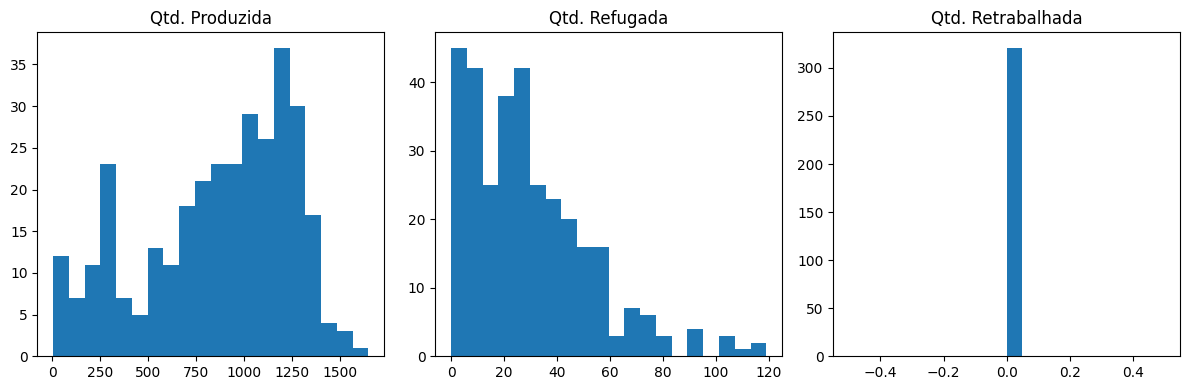

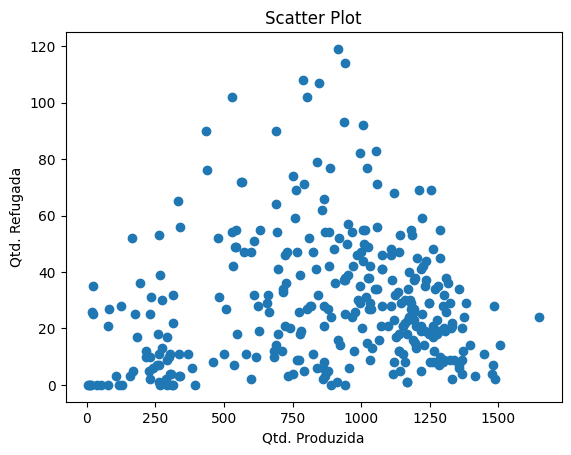

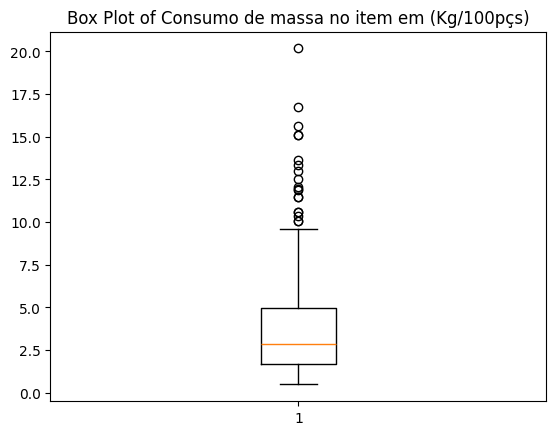

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix plot
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Generate a table with descriptive statistics
print(
    df[["Qtd. Produzida", "Qtd. Refugada", "Qtd. Retrabalhada"]]
    .describe()
    .to_markdown(numalign="left", stralign="left")
)

# Create histograms
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.hist(df["Qtd. Produzida"], bins=20)
plt.title("Qtd. Produzida")
plt.subplot(132)
plt.hist(df["Qtd. Refugada"], bins=20)
plt.title("Qtd. Refugada")
plt.subplot(133)
plt.hist(df["Qtd. Retrabalhada"], bins=20)
plt.title("Qtd. Retrabalhada")
plt.tight_layout()
plt.show()

# Create a scatter plot
plt.scatter(df["Qtd. Produzida"], df["Qtd. Refugada"])
plt.xlabel("Qtd. Produzida")
plt.ylabel("Qtd. Refugada")
plt.title("Scatter Plot")
plt.show()

# Create a box plot
plt.boxplot(df["Consumo de massa no item em (Kg/100pçs)"])
plt.title("Box Plot of Consumo de massa no item em (Kg/100pçs)")
plt.show()

# Resultados da Análise

Esta seção resume os principais resultados da análise exploratória.

## Sumário de Quantidades

*   **Total Qtd. Produzida:** 276484
*   **Total Qtd. Refugada:** 9378
*   **Total Qtd. Retrabalhada:** 0

## Valores Únicos

*   **Fator Un.:** \[3 4 5 6 2 1 63]
*   **Cód. Un.:** \['PC']
*   **Descrição da massa (Composto):** \['N148/18' 'F403/32' 'F424/40' 'F420/191' 'S316/2' 'S315/10' 'P212/1' 'P250/14' 'N146/9' 'N-142/67' 'F444/1' 'F420/95']

## Correlação

*   **Qtd. Produzida e Qtd. Refugada:** 0.0949586
*   **Qtd. Produzida e Qtd. Retrabalhada:** NaN (Não aplicável/Sem correlação)
*   **Qtd. Refugada e Qtd. Retrabalhada:** NaN (Não aplicável/Sem correlação)

## Variação do Consumo de Massa

*   **Amplitude:** (0.48, 20.172)

## Estatísticas Descritivas

A tabela de estatísticas descritivas mostra que a quantidade média produzida (`Qtd. Produzida`) é 861, com um desvio padrão de 401, indicando uma ampla variação nas quantidades de produção. A quantidade de itens refugados (`Qtd. Refugada`) é significativamente menor, com uma média de 29 e um desvio padrão de 42. Não houve itens retrabalhados (`Qtd. Retrabalhada`), conforme indicado pelos valores zero em todas as estatísticas.

## Histogramas

Os histogramas representam visualmente a distribuição dessas quantidades, mostrando que `Qtd. Produzida` tem uma distribuição assimétrica à direita (ou positiva), enquanto `Qtd. Refugada` e `Qtd. Retrabalhada` são fortemente assimétricas à direita, concentradas em zero.

## Gráfico de Dispersão

O gráfico de dispersão comparando `Qtd. Produzida` e `Qtd. Refugada` mostra uma correlação positiva fraca, indicando uma leve tendência de aumento na quantidade de itens refugados com o aumento da quantidade produzida.

## Box Plot do Consumo de Massa

O box plot para `Consumo de massa no item em (Kg/100pçs)` revela que a distribuição é assimétrica à direita, com uma mediana em torno de 5 e vários outliers (valores atípicos) na extremidade superior, indicando algumas ocorrências de alto consumo de material.

## Conclusões

Esses achados fornecem uma visão geral abrangente do processo de produção, destacando as quantidades produzidas, refugadas e retrabalhadas, bem como os fatores, unidades, materiais e suas relações. A análise também revela a distribuição do consumo de material e potenciais outliers.

Unique values of Manutencao: [355 354 353 352 351 350 349 348 347 346 345 344 342 341 340 339 338 337
 335 334 333 332 331 330 328 327 326 325 324 323 321 320 319 318 317 316
 314 313 312 311 310 309 308 306 305 304 303 302 300 299 298 297 296 293
 292 291 290 289 288 284 283 282 281 279 278 277 276 275 274 273 272 271
 270 269 268 267 266 265 264 263 262 261 260 259 258 257 256 255 254 253
 251 250 249 248 247 246 244 243 242 241 240 239 237 236 235 234 233 232
 231 230 229 228 227 226 225 223 222 221 220 219 218 217 216 215 214 213
 212 211 208 207 206 205 204 203 202 201 200 199 198 197 196 195 194 193
 192 191 190 189 188 187 186 185 184 183 182 181 180 179 178 177 176 175
 174 173 172 171 170 169 168 167 166 165 164 163 162 161 160 159 158 157
 156 155 154 153 152 151 150 149 148 147 146 145 144 143 142 141 139 138
 137 136 135 134 133 132 131 130 129 128 127 126 125 124 123 122 121 120
 119 118 117 116 115 114 113 112 111 110 109 108 107 106 105 104 103 102
 101  96  95  94  93  

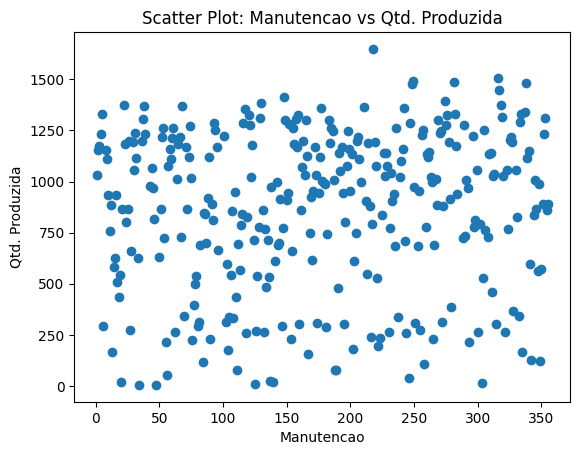

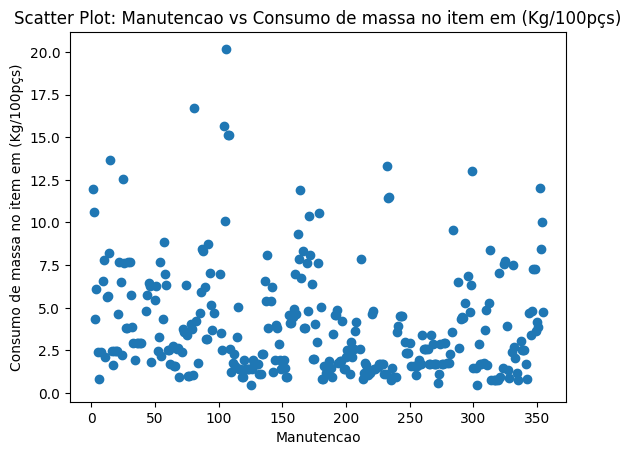

In [5]:
# Print the unique values of `Manutencao`
print(f"Unique values of Manutencao: {df['Manutencao'].unique()}")

# Calculate and print the correlation between `Manutencao` and `Qtd. Produzida`, `Qtd. Refugada` and `Qtd. Retrabalhada`
correlation_manutencao = df[
    ["Manutencao", "Qtd. Produzida", "Qtd. Refugada", "Qtd. Retrabalhada"]
].corr()
print(
    "Correlation between Manutencao, Qtd. Produzida, Qtd. Refugada, and Qtd. Retrabalhada:"
)
print(correlation_manutencao.to_markdown(numalign="left", stralign="left"))

# Calculate and print the correlation between `Manutencao` and `Consumo de massa no item em (Kg/100pçs)`
correlation_consumo = df[
    ["Manutencao", "Consumo de massa no item em (Kg/100pçs)"]
].corr()
print("Correlation between Manutencao and Consumo de massa no item em (Kg/100pçs):")
print(correlation_consumo.to_markdown(numalign="left", stralign="left"))

# Calculate and print the average and standard deviation of `Qtd. Produzida`, `Qtd. Refugada` and `Qtd. Retrabalhada` for the `Descrição da massa (Composto)` values 'N148/18' and 'F420/95'
for descricao in ["N148/18", "F420/95"]:
    print(f"\nDescriptive statistics for Descrição da massa (Composto) = {descricao}:")
    print(
        df[df["Descrição da massa (Composto)"] == descricao][
            ["Qtd. Produzida", "Qtd. Refugada", "Qtd. Retrabalhada"]
        ]
        .agg(["mean", "std"])
        .to_markdown(numalign="left", stralign="left")
    )

# Create a scatter plot to compare `Manutencao` and `Qtd. Produzida`
plt.scatter(df["Manutencao"], df["Qtd. Produzida"])
plt.xlabel("Manutencao")
plt.ylabel("Qtd. Produzida")
plt.title("Scatter Plot: Manutencao vs Qtd. Produzida")
plt.show()

# Create a scatter plot to compare `Manutencao` and `Consumo de massa no item em (Kg/100pçs)`
plt.scatter(df["Manutencao"], df["Consumo de massa no item em (Kg/100pçs)"])
plt.xlabel("Manutencao")
plt.ylabel("Consumo de massa no item em (Kg/100pçs)")
plt.title("Scatter Plot: Manutencao vs Consumo de massa no item em (Kg/100pçs)")
plt.show()

# Resultados da Análise da Coluna Manutenção

Esta seção resume os principais resultados da análise da coluna `Manutencao` e sua relação com outras variáveis.

## Valores Únicos de Manutenção

*   **Valores Únicos:** \[355 354 353 352 351 350 349 348 347 346 345 344 343 342 341 340 339 338 337 336 335 334 333 332 331 330 329 328 327 326 325 324 323 322 321 320 319 318 317 316 315 314 313 312 311 310 309 308 307 306 305 304 303 302 301 300 299 298 297 296 295 294 293 292 291 290 289 288 287 286 285 284 283 282 281 280 279 278 277 276 275 274 273 272 271 270 269 268 267 266 265 264 263 262 261 260 259 258 257 256 255 254 253 252 251 250 249 248 247 246 245 244 243 242 241 240 239 238 237 236 235 234 233 232 231 230 229 228 227 226 225 224 223 222 221 220 219 218 217 216 215 214 213 212 211 210 209 208 207 206 205 204 203 202 201 200 199 198 197 196 195 194 193 192 191 190 189 188 187 186 185 184 183 182 181 180 179 178 177 176 175 174 173 172 171 170 169 168 167 166 165 164 163 162 161 160 159 158 157 156 155 154 153 152 151 150 149 148 147 146 145 144 143 142 141 140 139 138 137 136 135 134 133 132 131 130 129 128 127 126 125 124 123 122 121 120 119 118 117 116 115 114 113 112 111 110 109 108 107 106 105 104 103 102 101 100  99  98  97  96  95  94  93  92  91  90  89  88  87  86  85  84  83  82  81  80  79  78  77  76  75  74  73  72  71  70  69  68  67  66  65  64  63  62  61  60  59  58  57  56  55  54  53  52  51  50  49  48  47  46  45  44  43  42  41  40  39  38  37  36  35  34  33  32  31  30  29  28  27  26  25  24  23  22  21  20  19  18  17  16  15  14  13  12  11  10   9   8   7   6   5   4   3   2   1]
## Correlação

*   **Manutenção e Qtd. Produzida:** -0.054818
*   **Manutenção e Qtd. Refugada:** -0.048461
*   **Manutenção e Qtd. Retrabalhada:** NaN (Não aplicável/Sem correlação)
*   **Manutenção e Consumo de massa no item em (Kg/100pçs):** 0.124399

## Estatísticas Descritivas por Composto

*   **Descrição da massa (Composto) = N148/18:**
    *   `Qtd. Produzida`: Média = 989, Desvio Padrão = 444
    *   `Qtd. Refugada`: Média = 30, Desvio Padrão = 44
    *   `Qtd. Retrabalhada`: Média = 0, Desvio Padrão = 0
*   **Descrição da massa (Composto) = F420/95:**
    *   `Qtd. Produzida`: Média = 1243, Desvio Padrão = 446
    *   `Qtd. Refugada`: Média = 15, Desvio Padrão = 23
    *   `Qtd. Retrabalhada`: Média = 0, Desvio Padrão = 0

## Gráficos de Dispersão

*   O gráfico de dispersão comparando `Manutencao` e `Qtd. Produzida` mostra uma leve tendência negativa, indicando uma tendência de diminuição na quantidade produzida à medida que os valores de manutenção aumentam. No entanto, o coeficiente de correlação é baixo (-0.054818), sugerindo uma relação fraca.

*   O gráfico de dispersão comparando `Manutencao` e `Consumo de massa no item em (Kg/100pçs)` mostra uma leve tendência positiva, indicando uma leve tendência de aumento no consumo de material à medida que os valores de manutenção aumentam. O coeficiente de correlação também é baixo (0.124399), sugerindo uma relação fraca.

## Análise por Composto

A análise dos valores de `Descrição da massa (Composto)` 'N148/18' e 'F420/95' mostra que 'F420/95' tem uma média de `Qtd. Produzida` maior (1243) em comparação com 'N148/18' (989), enquanto 'N148/18' tem uma média de `Qtd. Refugada` maior (30) em comparação com 'F420/95' (15).

## Conclusões

Esses achados fornecem insights sobre os dados de manutenção, sua relação com as métricas de produção e o consumo de material, variações na produção entre diferentes materiais e tendências